# Inference Notebook — Per-Component RUL Prediction
Loads the saved model and scaler. No training required.

**Run order:** Just run all cells top to bottom.

## 1. Imports

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.autograd import Function

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
WINDOW_SIZE  = 20
MAX_RUL      = 300.0
COMPONENT_NAMES = ['Battery', 'Motor', 'Brakes', 'Tires', 'Suspension']

SENSOR_COLS = [
    'SoC', 'SoH', 'Battery_Voltage', 'Battery_Current',
    'Battery_Temperature', 'Charge_Cycles', 'Motor_Temperature',
    'Motor_Vibration', 'Motor_Torque', 'Motor_RPM', 'Power_Consumption',
    'Brake_Pad_Wear', 'Brake_Pressure', 'Reg_Brake_Efficiency',
    'Tire_Pressure', 'Tire_Temperature', 'Suspension_Load',
    'Ambient_Temperature', 'Ambient_Humidity', 'Load_Weight',
    'Driving_Speed', 'Distance_Traveled', 'Idle_Time', 'Route_Roughness'
]
print(f'Device: {DEVICE}')

Device: cpu


## 2. Redefine Model Architecture
The class definitions must be present to load the saved weights.

In [3]:
class GradientReversalFn(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.clone()
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lam * grad_output, None

class GRL(nn.Module):
    def __init__(self):
        super().__init__()
        self.lam = 0.0
    def set_lambda(self, lam):
        self.lam = lam
    def forward(self, x):
        return GradientReversalFn.apply(x, self.lam)

class CNNFeatureExtractor(nn.Module):
    def __init__(self, n_sensors=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_sensors, 64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

class ComponentRULHead(nn.Module):
    def __init__(self, feat_dim=128, name=''):
        super().__init__()
        self.name = name
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),       nn.ReLU(),
            nn.Linear(32, 1),        nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class DomainDiscriminator(nn.Module):
    def __init__(self, feat_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),       nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

class MultiComponentDANN(nn.Module):
    def __init__(self, component_names=COMPONENT_NAMES):
        super().__init__()
        self.feature_extractor    = CNNFeatureExtractor()
        self.grl                  = GRL()
        self.domain_discriminator = DomainDiscriminator()
        self.rul_heads = nn.ModuleDict({
            name: ComponentRULHead(name=name)
            for name in component_names
        })
    def forward(self, x):
        features    = self.feature_extractor(x)
        rul_preds   = torch.cat(
            [self.rul_heads[name](features) for name in COMPONENT_NAMES], dim=1
        )
        domain_pred = self.domain_discriminator(self.grl(features))
        return rul_preds, domain_pred

print('Architecture defined.')

Architecture defined.


## 3. Load Saved Model & Scaler

In [4]:
MODEL_PATH  = '../models/cnn_dann_rul.pth'
SCALER_PATH = '../models/scaler.pkl'

# Load model
model = MultiComponentDANN().to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print('Model loaded successfully.')

# Load scaler
with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)
print('Scaler loaded successfully.')

Model loaded successfully.
Scaler loaded successfully.


## 4. Predict Function

In [5]:
def predict_rul(raw_window_df):
    """
    Predict RUL for all 5 components from a window of raw sensor readings.

    Args:
        raw_window_df : pd.DataFrame — exactly 20 rows, 24 sensor columns (raw, unscaled)
    Returns:
        dict: {component: predicted_RUL_cycles}
    """
    assert len(raw_window_df) == WINDOW_SIZE, \
        f'Need exactly {WINDOW_SIZE} rows, got {len(raw_window_df)}'

    scaled = scaler.transform(raw_window_df[SENSOR_COLS].values).astype(np.float32)
    x      = torch.tensor(scaled).unsqueeze(0).permute(0, 2, 1).to(DEVICE)

    with torch.no_grad():
        rul_norm, _ = model(x)

    rul_vals = (rul_norm.cpu().numpy()[0] * MAX_RUL).tolist()
    return dict(zip(COMPONENT_NAMES, rul_vals))


print('predict_rul() ready.')

predict_rul() ready.


## 5. Load Test Data & Predict

In [6]:
TEST_CSV = '../data/test_data.csv'   # generated by generate_test_data.py

test_df = pd.read_csv(TEST_CSV)
print(f'Test data shape : {test_df.shape}')
print(test_df.head(3))

Test data shape : (100, 25)
             Timestamp       SoC       SoH  Battery_Voltage  Battery_Current  \
0  2024-06-01 00:00:00  0.540035  0.944566       386.828168       -27.050665   
1  2024-06-01 00:15:00  0.797438  0.952793       374.691864       -13.201508   
2  2024-06-01 00:30:00  0.767453  0.943434       376.309320       -16.088648   

   Battery_Temperature  Charge_Cycles  Motor_Temperature  Motor_Vibration  \
0            36.028848     158.992559          50.723758         0.223265   
1            40.036044     162.356249          56.501190         0.437571   
2            40.276966     157.344392          56.759501         0.227981   

   Motor_Torque  ...  Tire_Pressure  Tire_Temperature  Suspension_Load  \
0    109.422140  ...      36.430604         42.867591      1151.980171   
1    119.191680  ...      35.537565         45.942400      1345.567508   
2    123.642974  ...      36.173244         48.881640      1278.569879   

   Ambient_Temperature  Ambient_Humidity  Loa

In [7]:
# Predict on every valid window in the test data
all_predictions = []

for i in range(WINDOW_SIZE, len(test_df) + 1):
    window = test_df.iloc[i - WINDOW_SIZE : i]
    preds  = predict_rul(window)
    preds['timestep'] = i - 1
    all_predictions.append(preds)

pred_df = pd.DataFrame(all_predictions).set_index('timestep')
print(f'Predictions shape: {pred_df.shape}')
print()
print('Last window prediction:')
for comp, rul in predict_rul(test_df.iloc[-WINDOW_SIZE:]).items():
    bar    = '█' * int(rul / MAX_RUL * 30)
    status = 'CRITICAL' if rul < 50 else 'WARNING' if rul < 100 else 'OK'
    print(f'  {comp:12s}: {rul:6.1f} cycles  {bar:<30}  [{status}]')

Predictions shape: (81, 5)

Last window prediction:
  Battery     :  202.1 cycles  ████████████████████            [OK]
  Motor       :  194.4 cycles  ███████████████████             [OK]
  Brakes      :  163.1 cycles  ████████████████                [OK]
  Tires       :  193.6 cycles  ███████████████████             [OK]
  Suspension  :   34.8 cycles  ███                             [CRITICAL]


c:\Users\adity\Downloads\RUL\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\adity\Downloads\RUL\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\adity\Downloads\RUL\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\adity\Downloads\RUL\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\adity\Downloads\RUL\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Us

## 6. Visualise RUL Over Time

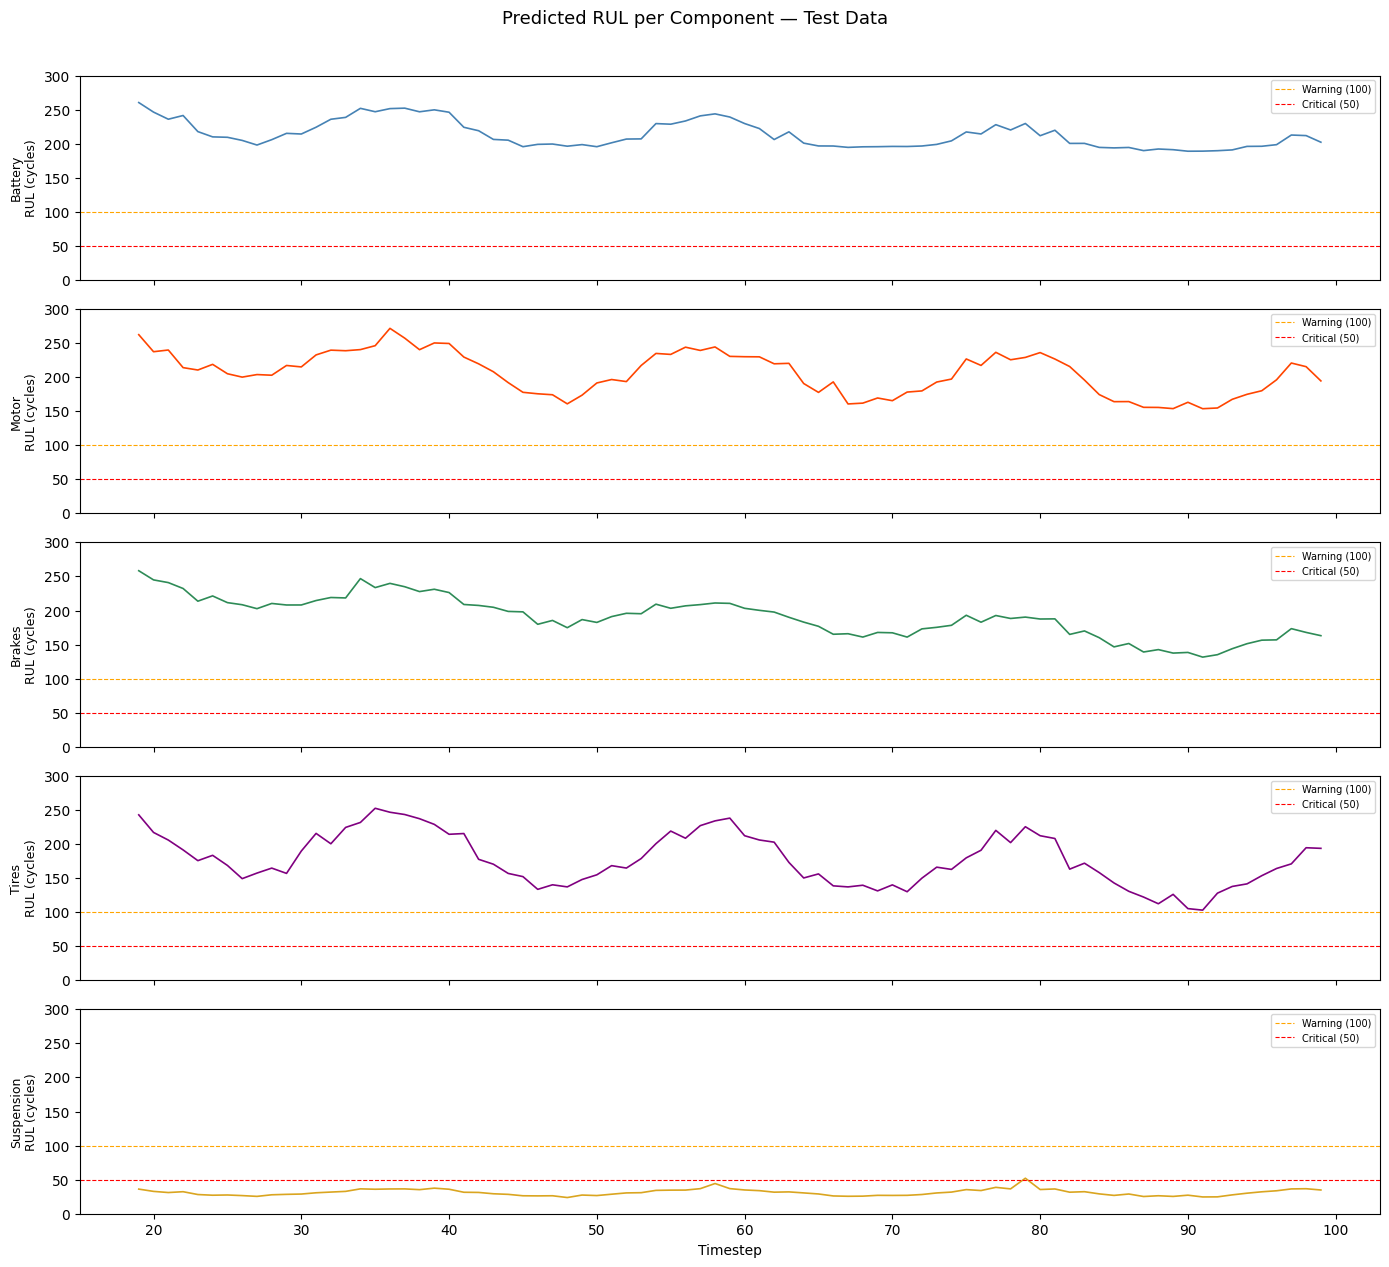

In [8]:
colors = ['steelblue', 'orangered', 'seagreen', 'purple', 'goldenrod']

fig, axes = plt.subplots(N_COMPONENTS := len(COMPONENT_NAMES), 1,
                          figsize=(14, N_COMPONENTS * 2.5), sharex=True)

for ax, comp, color in zip(axes, COMPONENT_NAMES, colors):
    ax.plot(pred_df.index, pred_df[comp], color=color, linewidth=1.2)
    ax.axhline(100, color='orange', linewidth=0.8, linestyle='--', label='Warning (100)')
    ax.axhline(50,  color='red',    linewidth=0.8, linestyle='--', label='Critical (50)')
    ax.set_ylabel(f'{comp}\nRUL (cycles)', fontsize=9)
    ax.set_ylim(0, MAX_RUL)
    ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Timestep')
fig.suptitle('Predicted RUL per Component — Test Data', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Predictions

In [9]:
pred_df.to_csv('../results/test_predictions.csv')
print('Saved: ../results/test_predictions.csv')
print(pred_df.describe().round(1))

Saved: ../results/test_predictions.csv
       Battery  Motor  Brakes  Tires  Suspension
count     81.0   81.0    81.0   81.0        81.0
mean     213.4  206.0   190.6  177.4        31.3
std       19.6   30.7    29.6   37.7         4.8
min      188.9  153.6   131.7  102.9        23.7
25%      196.5  177.7   167.9  149.1        27.2
50%      206.7  210.4   191.1  170.8        30.9
75%      228.5  230.4   209.3  208.4        34.8
max      260.3  271.5   258.4  252.4        52.1
